# 회로 메커니즘과 재사용 가능한 회로 구조

**목표.** Qiskit v2.x 자격증 시험에 필요한 최소한의 회로 객체 메커니즘을 익힌다. 즉, `QuantumCircuit`을 확인하고, 재사용 가능한 블록을 합성하며, 하위 회로를 instruction/gate로 변환하고, parameter를 바인딩하며, 의도적으로 측정을 추가하는 방법을 다룬다.

## 요약 대상 source notebook

| Source notebook | 중요하게 볼 내용 | 가볍게 볼 내용 |
|---|---|---|
| `2_4_Circuit_Mechanics.ipynb` | `QuantumCircuit` 객체, `data`, register, `append`, `compose`, `to_instruction`, `to_gate`, `decompose`, `depth`, `count_ops` | 시각화와 출력이 많은 긴 예제 |
| `4_Construct_Quantum_Circuits.ipynb` | 회로 구성 workflow와 반복적인 회로 생성 패턴 | 반복되는 gate 예제 |
| `2_2_Advanced_Circuits.ipynb` | 다중 qubit 블록과 재사용 가능한 subcircuit | standard gate와 중복되는 예제 |
| `2_Construct_Parameterized_Circuits.ipynb` | `Parameter`, `ParameterVector`, `assign_parameters` | 긴 template sweep 예제 |

**핵심 아이디어.** `QuantumCircuit`은 프로그램과 같은 container이면서 동시에 재사용 가능한 component의 source가 될 수 있다. 시험 대비 관점에서는 circuit, instruction, gate, decomposed circuit 사이를 오가는 방법에 익숙해야 한다.

In [19]:
from math import pi
from qiskit import QuantumCircuit
from qiskit.circuit import QuantumRegister, ClassicalRegister, Parameter

## 1. Quantum Circuit의 기초

**두 가지 형태**: Abstract circuit / Physical 또는 ISA circuit

### APIs
정보 단위:
- **Bits**: `Qubit` 또는 `Clbit`
- **Register**: bit의 모음, `QuantumRegister`, `ClassicalRegister`

연산자:
- **Gate**: Unitary instruction 또는 `ControlledGate`. (`Instruction`을 상속함)
- **Instruction**: Hardware 기반 instruction, `Barrier`, `Delay`, `Measure`, `Reset`, `Store`, `ControlFlowOp`

Variable:
- **Variable**: 회로 안에 존재하는 type이 지정된 classical storage location.
- **Expression**: 실행 중 평가되는 classical expression.
- **Type**: expression의 classical type.

Parameter:
- `Parameter`, `ParameterExpression`, `ParameterVector`, `ParameterVectorElement`.

추가:
- **EquivalenceLibrary**: gate나 instruction을 다른 gate들로 다시 쓸 수 있는 alternative decomposition database.
- **SessionEquivalenceLibrary**: 현재 session에서 공유되는 Qiskit의 기본 equivalence library로, transpilation과 decomposition 과정에서 standard gate decomposition을 찾는 데 사용된다.

## 2. Circuit 객체 확인하기

Circuit은 순서가 있는 instruction들을 `qc.data`에 저장한다. 각 항목은 operation과 그것이 작용하는 qubit/clbit을 기록한다. 시험 관점에서 유용한 attribute와 method는 `num_qubits`, `num_clbits`, `depth()`, `count_ops()`, `parameters`, `draw()`이다.

In [20]:
qr = QuantumRegister(2, "q")
cr = ClassicalRegister(2, "c")
qc = QuantumCircuit(qr, cr, name="bell_demo")

qc.h(qr[0])
qc.cx(qr[0], qr[1])
qc.measure(qr, cr)

print("qubits:", qc.num_qubits)
print("clbits:", qc.num_clbits)
print("depth:", qc.depth())
print("ops:", qc.count_ops())
print("first instruction:", qc.data[0].operation.name)
qc.draw("text")

qubits: 2
clbits: 2
depth: 3
ops: OrderedDict({'measure': 2, 'h': 1, 'cx': 1})
first instruction: h


┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

## 3. 재사용 가능한 subcircuit 합성하기

재사용할 객체가 아직 circuit일 때는 `compose`를 사용한다. 주의할 점은, `inplace=True`를 주지 않으면 `compose`는 새로운 circuit을 반환하고 원래 circuit은 바꾸지 않는다는 것이다.

In [21]:
def bell_block() -> QuantumCircuit:
    block = QuantumCircuit(2, name="BellBlock")
    block.h(0)
    block.cx(0, 1)
    return block

main = QuantumCircuit(4, name="main")
block = bell_block()

# 2-qubit block을 인접하지 않은 logical qubit 1과 3에 합성한다.
main.compose(block, qubits=[1, 3], inplace=True)

print(main.count_ops())
main.draw("text")

OrderedDict({'h': 1, 'cx': 1})


q_0: ──────────
     ┌───┐     
q_1: ┤ H ├──■──
     └───┘  │  
q_2: ───────┼──
          ┌─┴─┐
q_3: ─────┤ X ├
          └───┘

## 4. Circuit을 instruction 또는 gate로 변환하기

Circuit을 재사용 가능한 instruction으로 묶으려면 `to_instruction()`을 사용한다. Circuit이 unitary라면 `to_gate()`를 통해 `Gate`로 만들 수 있고, 이후 `.control()`로 controlled gate를 만들 수 있다.

In [22]:
block_inst = bell_block().to_instruction()

qc_inst = QuantumCircuit(4)
qc_inst.append(block_inst, [0, 1])
qc_inst.append(block_inst, [2, 3])

print(qc_inst.count_ops())
print("After decomposition:", qc_inst.decompose().count_ops())
qc_inst.draw("text")

OrderedDict({'BellBlock': 2})
After decomposition: OrderedDict({'h': 2, 'cx': 2})


┌────────────┐
q_0: ┤0           ├
     │  BellBlock │
q_1: ┤1           ├
     ├────────────┤
q_2: ┤0           ├
     │  BellBlock │
q_3: ┤1           ├
     └────────────┘

In [23]:
# Unitary subcircuit -> Gate -> controlled gate
single = QuantumCircuit(1, name="my_rx_like")
theta = Parameter("θ")
single.rx(theta, 0)

ctrl_gate = single.to_gate().control(1)
controlled_template = QuantumCircuit(2)
controlled_template.append(ctrl_gate, [0, 1])

bound = controlled_template.assign_parameters({theta: pi / 4})
print("unbound parameters:", bound.parameters)
bound.draw("text")

unbound parameters: ParameterView([])


q_0: ─────────■─────────
     ┌────────┴────────┐
q_1: ┤ my_rx_like(π/4) ├
     └─────────────────┘

## 5. Parameterized reusable template

Parameterized circuit은 numerical value가 정해지기 전에 재사용할 수 있다. 아직 바인딩되지 않은 parameter가 남아 있는지는 `parameters`로 확인하고, 값을 대입할 때는 `assign_parameters`를 사용한다.

In [24]:
def layer(theta: Parameter) -> QuantumCircuit:
    qc = QuantumCircuit(2, name="layer")
    qc.ry(theta, 0)
    qc.cx(0, 1)
    return qc

alpha = Parameter("α")
template = QuantumCircuit(2, name="template")
template.compose(layer(alpha), inplace=True)
template.compose(layer(2 * alpha), inplace=True)

print("parameters before binding:", template.parameters)
bound_template = template.assign_parameters({alpha: 0.2})
print("parameters after binding:", bound_template.parameters)
bound_template.draw("text")

parameters before binding: ParameterView([Parameter(α)])
parameters after binding: ParameterView([])


┌─────────┐     ┌─────────┐     
q_0: ┤ Ry(0.2) ├──■──┤ Ry(0.4) ├──■──
     └─────────┘┌─┴─┐└─────────┘┌─┴─┐
q_1: ───────────┤ X ├───────────┤ X ├
                └───┘           └───┘

## 6. Box

`box`는 여러 operation을 하나의 시각적/컴파일러 블록으로 묶는다. 다만 이것을 재사용 가능한 gate로 바꾸는 것은 아니다. 예를 들어 scheduling, duration, annotation 등을 위해 특정 영역을 함께 유지하고 싶을 때 유용하다.

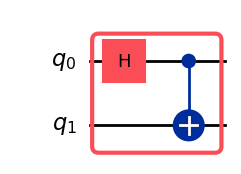

In [25]:
qc = QuantumCircuit(2)
with qc.box():
    qc.h(0)
    qc.cx(0, 1)
qc.draw("mpl")

## 7. Instruction subclass

상속 관계:

```text
Instruction
└── Gate
    └── ControlledGate
```

직접 custom subclass를 작성하기보다는 보통 `to_instruction()` 또는 `to_gate()`를 사용하는 것이 좋다.

In [26]:
inst = bell_block().to_instruction()
gate = bell_block().to_gate()
ctrl = gate.control(1)

In [27]:
inst.control(1)

AttributeError: 'Instruction' object has no attribute 'control'

## 요약

| 목적 | 주요 표현 | 의미 |
|---|---|---|
| Circuit 확인 | `qc.data`, `qc.depth()`, `qc.count_ops()` | 저장된 instruction과 circuit 크기를 확인 |
| Circuit block 합성 | `qc.compose(block, qubits=[...], inplace=False, ...)` | 다른 circuit을 선택한 wire에 삽입 |
| Instruction 추가 | `qc.append(inst, qargs, cargs)` | `Instruction` 또는 `Gate`를 직접 추가 |
| Subcircuit 패키징 | `sub.to_instruction()` | 재사용 가능한 instruction으로 변환 |
| Unitary subcircuit 패키징 | `sub.to_gate()` | 재사용 가능한 gate로 변환 |
| Controlled reusable block | `sub.to_gate().control(k)` | unitary block에 control qubit 추가 |
| Parameter 바인딩 | `qc.assign_parameters({theta: value})` | symbolic parameter를 숫자로 치환 |
| Decompose | `qc.decompose()` | 패키징된 instruction을 lower-level gate로 전개 |
| Measure | `qc.measure(q, c)`, `qc.measure_all()` | measurement operation 추가 |
| 영역 묶기 | `with qc.box(): ...` | operation들을 boxed region 안에 유지 |

## 연습문제

1. 다음 코드를 실행한 뒤 `a.depth()`는 무엇인가?

```python
def bell_block() -> QuantumCircuit:
    block = QuantumCircuit(2, name="BellBlock")
    block.h(0)
    block.cx(0, 1)
    return block

a = QuantumCircuit(2)
b = bell_block()
a.compose(b, [0, 1])
```

a) `0`  
b) `1`  
c) `2`  
d) error가 발생한다.

2. `b`를 qubit 0과 1에 삽입하면서 `a` 자체를 변경하는 표현은 무엇인가?

a) `a.compose(b, [0, 1])`  
b) `a.compose(b, [0, 1], inplace=True)`  
c) `b.compose(a, [0, 1])`  
d) `a.decompose(b)`

3. Measurement와 같은 non-unitary operation을 포함할 수 있는 재사용 가능한 circuit을 패키징할 때 사용할 method는 무엇인가?

a) `to_gate()`  
b) `to_instruction()`  
c) `control()`  
d) `assign_parameters()`

4. 재사용 가능한 unitary subcircuit에 `.control()`을 호출하기 전에 사용해야 하는 method는 무엇인가?

a) `to_instruction()`  
b) `to_gate()`  
c) `measure_all()`  
d) `depth()`

5. 패키징된 instruction 내부의 gate들을 확인하는 표현은 무엇인가?

a) `qc.parameters`  
b) `qc.count_ops()`  
c) `qc.decompose()`  
d) `qc.num_clbits`

6. symbolic parameter가 아직 바인딩되지 않고 남아 있는지 확인하는 표현은 무엇인가?

a) `qc.parameters`  
b) `qc.data`  
c) `qc.qubits`  
d) `qc.cregs`

7. `Gate`와 `Instruction`의 관계를 가장 잘 설명한 것은 무엇인가?

a) 모든 `Instruction`은 `Gate`이다.  
b) 모든 `Gate`는 `Instruction`이지만, 모든 `Instruction`이 `Gate`인 것은 아니다.  
c) `QuantumCircuit`은 `Gate`의 subclass이다.  
d) `Measure`는 unitary gate이다.


## 간단한 정답 해설

1. **a)** `compose`는 결과를 assign하거나 `inplace=True`를 사용하지 않으면 원래 circuit을 바꾸지 않는다.
2. **b)** `inplace=True`는 원래 circuit을 직접 변경한다.
3. **b)** `to_instruction()`은 일반적인 circuit-like block을 패키징할 수 있다.
4. **b)** `.control()`은 gate method이므로, unitary subcircuit에는 `to_gate()`를 사용한다.
5. **c)** `decompose()`는 패키징된 instruction을 그 정의에 따라 전개한다.
6. **a)** `qc.parameters`는 아직 바인딩되지 않은 parameter들을 반환한다.
7. **b)** `Gate`는 `Instruction`의 unitary subclass이다. Measurement와 reset은 instruction이지만 gate는 아니다.